In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xg

In [ ]:
!pip install --upgrade setuptools wheel
!pip install prophet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.2 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 71.0.4
    Uninstalling setuptools-71.0.4:
      Successfully uninstalled setuptools-71.0.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


In [ ]:
df=pd.read_csv('crop_price_new.csv')

In [ ]:
df.head()

,State,City,Crop Type,Season,Temperature (°C),Rainfall (mm),Supply Volume (tons),Demand Volume (tons),Transportation Cost (₹/ton),Fertilizer Usage (kg/hectare),Pest Infestation (0-1),Market Competition (0-1),Price (₹/ton),Year,Month
0,Maharashtra,Mumbai,Wheat,Kharif,37.1,204.5,3583.93,1345.60,302.65,219.62,0.12,0.72,14.33,2023,January
1,Maharashtra,Mumbai,Wheat,Kharif,21.2,57.8,2944.07,1698.04,393.07,263.00,0.38,0.05,41.34,2023,February
2,Maharashtra,Mumbai,Wheat,Kharif,36.3,129.4,3956.04,2209.66,350.68,96.37,0.87,0.33,29.03,2023,March
3,Maharashtra,Mumbai,Wheat,Kharif,19.5,24.3,1651.50,576.15,274.45,192.04,0.51,0.28,14.45,2023,April
4,Maharashtra,Mumbai,Wheat,Kharif,36.6,218.2,2173.52,1185.90,382.61,136.45,0.86,0.17,20.01,2023,May


In [ ]:
t=df["Price (₹/ton)"]

In [ ]:
df.drop(columns=["Price (₹/ton)"],inplace=True)

In [ ]:
df["Price(₹/ton)"]=t

In [ ]:
df.head()

,State,City,Crop Type,Season,Temperature (°C),Rainfall (mm),Supply Volume (tons),Demand Volume (tons),Transportation Cost (₹/ton),Fertilizer Usage (kg/hectare),Pest Infestation (0-1),Market Competition (0-1),Year,Month,Price(₹/ton)
0,Maharashtra,Mumbai,Wheat,Kharif,37.1,204.5,3583.93,1345.60,302.65,219.62,0.12,0.72,2023,January,14.33
1,Maharashtra,Mumbai,Wheat,Kharif,21.2,57.8,2944.07,1698.04,393.07,263.00,0.38,0.05,2023,February,41.34
2,Maharashtra,Mumbai,Wheat,Kharif,36.3,129.4,3956.04,2209.66,350.68,96.37,0.87,0.33,2023,March,29.03
3,Maharashtra,Mumbai,Wheat,Kharif,19.5,24.3,1651.50,576.15,274.45,192.04,0.51,0.28,2023,April,14.45
4,Maharashtra,Mumbai,Wheat,Kharif,36.6,218.2,2173.52,1185.90,382.61,136.45,0.86,0.17,2023,May,20.01


Train Test split of data-

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=["Price(₹/ton)"]),df["Price(₹/ton)"],test_size=0.2,random_state=42)

Here, I have used Transformer under which feature Engineering and  prediction executed.using pipelining

In [ ]:
trf1=ColumnTransformer([("trf1",OneHotEncoder(sparse=False,handle_unknown="ignore",drop="first"),[0,1,2,3,12,13])],remainder="passthrough")

In [ ]:
trf2=ColumnTransformer([("trf2",StandardScaler(),slice(0,63))],remainder="passthrough")

In [ ]:
trf3=RandomForestRegressor(n_estimators=50,random_state=42)
# trf3=xg.XGBRegressor(Objective="reg:squarederror",eval_metric="rmse")

In [ ]:
from sklearn import set_config
set_config(display="diagram")

In [ ]:
pipe=make_pipeline(trf1,trf2,trf3)

In [ ]:

pipe.fit(x_train,y_train)

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('trf1',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse=False),
                                                  [0, 1, 2, 3, 12, 13])])),
                ('columntransformer-2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('trf2', StandardScaler(),
                                                  slice(0, 63, None))])),
                ('randomforestregressor',
                 RandomForestRegressor(n_estimators=50, random_state=42))])

In [ ]:
y_pred=pipe.predict(x_test)

In [ ]:
score=r2_score(y_test,y_pred)

In [ ]:
np.mean(cross_val_score(pipe,x_train,y_train,scoring="r2",cv=5))

0.9845714194144058

In [ ]:
train_rmse=mean_squared_error(y_train,pipe.predict(x_train),squared=False)
test_rmse=mean_squared_error(y_test,pipe.predict(x_test),squared=False)
print("Train RMSE:",train_rmse)
print("Test RMSE:",test_rmse)

Train RMSE: 3.876114273645897
Test RMSE: 9.849525853097997


In [ ]:
import pickle

In [ ]:
pickle.dump(pipe,open("pipe.pkl","wb"))

In [ ]:
pickle.dump(pipe,open("RFpipe.pkl","wb"))

In [ ]:
#display Adjusted_r_square-
1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

0.9856764677362102

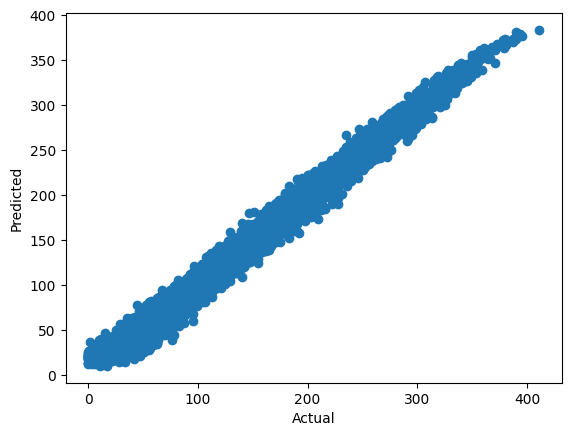

In [ ]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

<Axes: xlabel='Price(₹/ton)', ylabel='Density'>

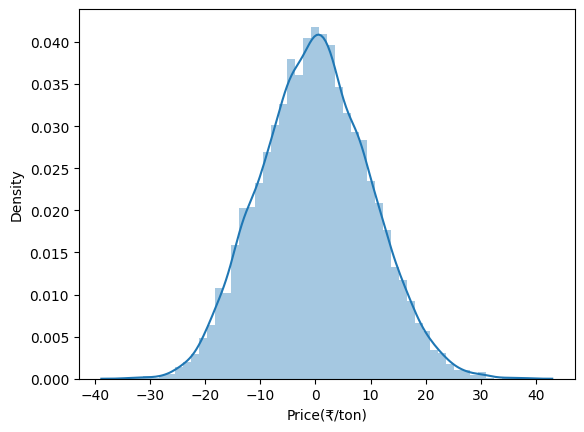

In [ ]:
residuals=y_test-y_pred
sns.distplot(residuals,kde=True
            )

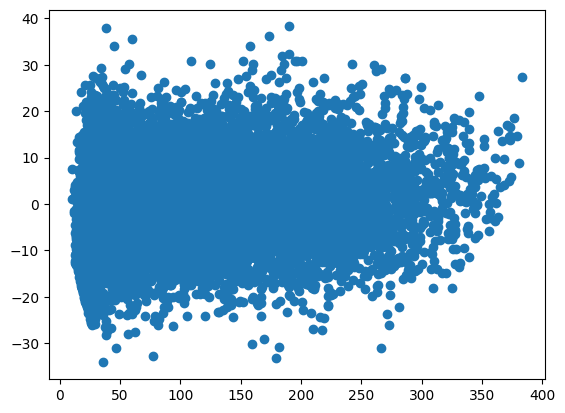

In [ ]:
plt.scatter(y_pred,residuals)

In [ ]:
test=pickle.load(open("RFpipe.pkl","rb"))


In [ ]:
df.sample(2)

,State,City,Crop Type,Season,Temperature (°C),Rainfall (mm),Supply Volume (tons),Demand Volume (tons),Transportation Cost (₹/ton),Fertilizer Usage (kg/hectare),Pest Infestation (0-1),Market Competition (0-1),Year,Month,Price(₹/ton)
38456,Karnataka,Davanagere,Wheat,Zaid,16.8,218.7,3125.92,4431.74,489.49,228.27,0.42,0.14,2023,September,130.91
1148,Maharashtra,Mumbai,Tea,Post-Monsoon,16.6,118.0,2067.09,3833.08,428.43,200.96,0.00,0.07,2024,September,155.05


In [ ]:
inpt=np.array(["Karnataka","Davanagere","Wheat","Zaid",16.8,218.7,3125.92,4431.74,489.49,228.27,0.42,0.14,2023,"September"],dtype=object).reshape(1,14)


In [ ]:
test.predict(inpt)

array([134.7636])

In [ ]:
import bz2
import pickle

# Load the pipeline (if not already loaded)
with open('pipe.pkl', 'rb') as f_in:
    model = pickle.load(f_in)

# Compress the pickle file using bz2
with bz2.BZ2File('pipe_compressed.pkl', 'wb') as f_out:
    pickle.dump(model, f_out)

print("File compressed successfully to pipe_compressed.pkl.bz2")


File compressed successfully to pipe_compressed.pkl.bz2


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmprmtfl_zd/g3j8p0ha.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmprmtfl_zd/mydsis9j.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=89320', 'data', 'file=/tmp/tmprmtfl_zd/g3j8p0ha.json', 'init=/tmp/tmprmtfl_zd/mydsis9j.json', 'output', 'file=/tmp/tmprmtfl_zd/prophet_model723x8sus/prophet_model-20240916071734.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
07:17:34 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
07:17:38 - cmdstanpy - INFO - Chain

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

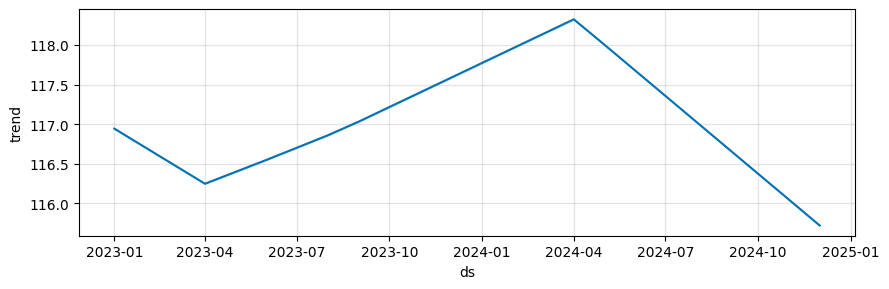

In [55]:


from prophet import Prophet

df=pd.read_csv("/content/crop_price_dataset_updated_hackathon.csv")

df.head()

t=df["Price (₹/ton)"]


df.drop(columns=["Unnamed: 0"],inplace=True)

x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=["Price (₹/ton)"]),df["Price (₹/ton)"],test_size=0.2,random_state=42)



ds =x_train["Date"].values
y = y_train.values
t=x_test["Date"].values
X_train_t=pd.DataFrame(columns=["ds"],data=t)


df1_prophet = pd.DataFrame({'ds': ds, 'y': y})
df_prophet=df1_prophet[["ds","y"]]

# Initialize and fit Prophet model
model = Prophet()
model.fit(df_prophet)




# Make predictions
forecast = model.predict(X_train_t)

# # Plot the forecast
# model.plot(forecast)

# Plot the forecast components
model.plot_components(forecast)















"""Here, I have used Transformer under which feature Engineering and  prediction executed.using pipelining"""

trf1=ColumnTransformer([("trf1",OneHotEncoder(sparse=False,handle_unknown="ignore",drop="first"),[0,1,2,3])],remainder="passthrough")

trf2=ColumnTransformer([("trf2",StandardScaler(),slice(0,51))],remainder="passthrough")

trf3=RandomForestRegressor(n_estimators=50,random_state=42)
# trf3=xg.XGBRegressor(Objective="reg:squarederror",eval_metric="rmse")



from sklearn import set_config
set_config(display="diagram")

pipe=make_pipeline(trf1,trf2,trf3)

y_train

x_train.drop(columns=["Date"])

pipe.fit(x_train.drop(columns=["Date"]),y_train)

rf_pred=pipe.predict(x_test.drop(columns=["Date"]))


# prophet library

from sklearn.ensemble import StackingRegressor

combined_features = np.column_stack((rf_pred,forecast["yhat"].values))

rf_pred

combined_features

final_model = RandomForestRegressor(n_estimators=100, random_state=42)
final_model.fit(combined_features, y_train)

final_pred = final_model.predict(combined_features)

# Evaluate the final predictions
print(final_pred)

score=r2_score(y_test,final_pred)

score

train_rmse=mean_squared_error(y_train,pipe.predict(x_train),squared=False)
test_rmse=mean_squared_error(y_test,pipe.predict(x_test),squared=False)
print("Train RMSE:",train_rmse)
print("Test RMSE:",test_rmse)



#display Adjusted_r_square-

#
#inpt=np.array(["Karnataka","Davanagere","Wheat","Zaid",16.8,218.7,3125.92,4431.74,489.49,228.27,0.42,0.14,2023,"September"],dtype=object).reshape(1,14)





In [54]:
train_forecast.

In [48]:
model.predict( pd.DataFrame({"ds": ['2023-01']}))

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2023-01-01,116.942674,7.795974,220.651905,116.942674,116.942674,0.0,0.0,0.0,0.0,0.0,0.0,116.942674


In [70]:
df[df["Price (₹/ton)"]==124.89]

,Date,State,City,Crop Type,Season,Temperature (°C),Rainfall (mm),Supply Volume (tons),Demand Volume (tons),Transportation Cost (₹/ton),Fertilizer Usage (kg/hectare),Pest Infestation (0-1),Market Competition (0-1),Price (₹/ton)
8897,2024-06-01,Punjab,Amritsar,Coffee,Zaid,39.4,225.5,678.43,2364.93,479.55,128.57,0.59,0.37,124.89
32771,2023-12-01,Karnataka,Hubli,Rice,Rabi,25.9,183.8,4779.48,1616.14,448.36,138.56,0.38,0.39,124.89


In [20]:
# Pickling the entire pipeline and models
with open('combined_model.pkl', 'wb') as file:
    pickle.dump({
        'pipe': pipe,  # RandomForest Pipeline
        'prophet_model': model,  # Prophet model
        'final_model': final_model  # Final combined RandomForest model
    }, file)

print("Models have been pickled successfully.")

Models have been pickled successfully.


In [37]:
import numpy as np
import pandas as pd

# Load the models
with open('combined_model.pkl', 'rb') as f:
    models = pickle.load(f)

# Unpack the models
pipe = models['pipe']
final_model = models['final_model']
prophet_model = models['prophet_model']

# Example input with Date and other features
#inpt = np.array(["2023-09-15", "Karnataka", "Davanagere", "Wheat", "Zaid", 16.8, 218.7, 3125.92, 4431.74, 489.49, 228.27, 0.42, 0.14], dtype=object).reshape(1, 13)
intpt=np.array(["2023-01","Maharashtra","Mumbai","Wheat","Kharif",37.1	,204.5,3583.93,1345.60,302.65,219.62,0.12,0.72],dtype=object).reshape(1,13)
# Step 1: Extract date and process it for Prophet
input_date = pd.DataFrame({"ds": [inpt[0, 0]]})  # Date for Prophet
rest_of_input = inpt[0, 1:].reshape(1, -1)  # Remaining features for pipeline

# Step 2: Make a prediction with the Prophet model
forecast_input = prophet_model.predict(input_date)
forecast_yhat = forecast_input["yhat"].values[0]  # Get predicted value from Prophet

# Step 3: Use the rest of the input with the pipeline (excluding the Date)
rf_pred = pipe.predict(rest_of_input)  # Get the pipeline prediction

# Step 4: Combine the features (RandomForest prediction + Prophet's forecast)
combined_features = np.column_stack((rf_pred, np.array([forecast_yhat])))

# Step 5: Use the final combined model for prediction
final_prediction = final_model.predict(combined_features)

# Print the final result
print("Final Predicted Price:", final_prediction)


Final Predicted Price: [137.1485]


In [40]:
forecast_yhat

117.11820620426381

In [27]:
df.head()

,Date,State,City,Crop Type,Season,Temperature (°C),Rainfall (mm),Supply Volume (tons),Demand Volume (tons),Transportation Cost (₹/ton),Fertilizer Usage (kg/hectare),Pest Infestation (0-1),Market Competition (0-1),Price (₹/ton)
0,2023-01,Maharashtra,Mumbai,Wheat,Kharif,37.1,204.5,3583.93,1345.60,302.65,219.62,0.12,0.72,14.33
1,2023-02,Maharashtra,Mumbai,Wheat,Kharif,21.2,57.8,2944.07,1698.04,393.07,263.00,0.38,0.05,41.34
2,2023-03,Maharashtra,Mumbai,Wheat,Kharif,36.3,129.4,3956.04,2209.66,350.68,96.37,0.87,0.33,29.03
3,2023-04,Maharashtra,Mumbai,Wheat,Kharif,19.5,24.3,1651.50,576.15,274.45,192.04,0.51,0.28,14.45
4,2023-05,Maharashtra,Mumbai,Wheat,Kharif,36.6,218.2,2173.52,1185.90,382.61,136.45,0.86,0.17,20.01


In [28]:
inpt1=np.array(["2023-01","Maharashtra","Mumbai","Wheat","Kharif",37.1	,204.5,3583.93,1345.60,302.65,219.62,0.12,0.72],dtype=object).reshape(1,13)

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from prophet import Prophet
import numpy as np

# Load the dataset
df = pd.read_csv("/content/crop_price_dataset_updated_hackathon.csv")

# Prepare data
df.drop(columns=["Unnamed: 0"], inplace=True)

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Split the data
X = df.drop(columns=["Price (₹/ton)"])
y = df["Price (₹/ton)"]
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Prepare data for Prophet
ds_train = x_train["Date"].values
y_train_values = y_train.values
ds_test = x_test["Date"].values

# Initialize and fit Prophet model
prophet_model = Prophet()
df_prophet = pd.DataFrame({'ds': ds_train, 'y': y_train_values})
prophet_model.fit(df_prophet)

# Make Prophet predictions
X_train_t = pd.DataFrame(columns=["ds"], data=ds_train)
X_test_t = pd.DataFrame(columns=["ds"], data=ds_test)
forecast_train = prophet_model.predict(X_train_t)
forecast_test = prophet_model.predict(X_test_t)

# Feature Engineering and Prediction Pipeline
trf1 = ColumnTransformer(
    [("onehot", OneHotEncoder(sparse=False, handle_unknown="ignore", drop="first"), [ 'State', 'City', 'Crop Type',"Season"])],
    remainder="passthrough"
)

trf2 = ColumnTransformer(
    [("scaler", StandardScaler(), slice(0, -1))],  # Scale all columns except the last one (Date)
    remainder="passthrough"
)

trf3 = RandomForestRegressor(n_estimators=50, random_state=42)

pipe = Pipeline(steps=[
    ('feature_engineering', trf1),
    ('scaling', trf2),
    ('regressor', trf3)
])

# Fit pipeline
pipe.fit(x_train.drop(columns=["Date"]), y_train)

# Predictions from pipeline
rf_pred_train = pipe.predict(x_train.drop(columns=["Date"]))
rf_pred_test = pipe.predict(x_test.drop(columns=["Date"]))

# Combine features for the final model
combined_features_train = np.column_stack((rf_pred_train, forecast_train["yhat"].values))
combined_features_test = np.column_stack((rf_pred_test, forecast_test["yhat"].values))

# Train and evaluate the final model
final_model = RandomForestRegressor(n_estimators=100, random_state=42)
final_model.fit(combined_features_train, y_train)
final_pred = final_model.predict(combined_features_test)

# Evaluate the final predictions
final_score = r2_score(y_test, final_pred)
train_rmse = mean_squared_error(y_train, final_model.predict(combined_features_train), squared=False)
test_rmse = mean_squared_error(y_test, final_pred, squared=False)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Final R2 Score:", final_score)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmprmtfl_zd/usdodcd5.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmprmtfl_zd/8sa1t35_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=1624', 'data', 'file=/tmp/tmprmtfl_zd/usdodcd5.json', 'init=/tmp/tmprmtfl_zd/8sa1t35_.json', 'output', 'file=/tmp/tmprmtfl_zd/prophet_modelll31hml8/prophet_model-20240916061009.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
06:10:09 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:10:13 - cmdstanpy - INFO - Chain 

Train RMSE: 1.5343210579732924
Test RMSE: 9.732586136121872
Final R2 Score: 0.9860349620797053


In [10]:
x_train.drop(columns=["Date"])

,State,City,Crop Type,Season,Temperature (°C),Rainfall (mm),Supply Volume (tons),Demand Volume (tons),Transportation Cost (₹/ton),Fertilizer Usage (kg/hectare),Pest Infestation (0-1),Market Competition (0-1)
596,Maharashtra,Mumbai,Millets,Kharif,32.3,262.7,4553.40,2429.76,117.34,231.92,0.15,0.63
30136,Karnataka,Bangalore,Tobacco,Post-Monsoon,25.9,208.7,2824.93,3413.32,391.13,285.20,0.17,0.53
8339,Punjab,Amritsar,Millets,Post-Monsoon,37.5,143.4,1353.77,3390.43,130.27,192.96,0.06,0.44
12824,Uttar Pradesh,Lucknow,Tobacco,Zaid,20.0,288.3,1042.71,4084.07,304.19,171.58,0.54,0.64
22894,Tamil Nadu,Madurai,Onion,Rabi,32.3,179.3,1006.59,2840.57,103.86,74.09,0.51,0.68
...,...,...,...,...,...,...,...,...,...,...,...,...
11284,Punjab,Patiala,Potato,Zaid,35.8,75.8,1629.78,4289.04,425.99,296.96,0.47,0.45
44732,Karnataka,Bellary,Pulses,Post-Monsoon,24.5,67.7,3193.08,605.00,58.62,95.33,0.03,0.59
38158,Karnataka,Belgaum,Potato,Rabi,16.9,129.2,4231.24,2640.12,473.77,270.93,0.57,0.35
860,Maharashtra,Mumbai,Groundnut,Post-Monsoon,23.4,239.3,1384.92,3513.39,487.16,278.09,0.01,0.16


In [66]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from prophet import Prophet
import numpy as np
import pickle
from sklearn.base import BaseEstimator, TransformerMixin

# Load the dataset
df = pd.read_csv("/content/crop_price_dataset_updated_hackathon.csv")

# Prepare data
df.drop(columns=["Unnamed: 0"], inplace=True)

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Split the data
X = df.drop(columns=["Price (₹/ton)"])
y = df["Price (₹/ton)"]
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Custom transformer for Prophet (fit and predict separately)
class ProphetTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.prophet_model = Prophet()

    def fit(self, X, y=None):
        df_prophet = pd.DataFrame({'ds': X['Date'], 'y': y})
        self.prophet_model.fit(df_prophet)
        return self

    def transform(self, X, y=None):
        future_dates = pd.DataFrame({'ds': X['Date']})
        forecast = self.prophet_model.predict(future_dates)
        return forecast[['yhat']].values

# Step 1: Create the transformer pipeline for RandomForestRegressor
trf1 = ColumnTransformer(
    [("onehot", OneHotEncoder(sparse=False, handle_unknown="ignore", drop="first"), ['State', 'City', 'Crop Type', "Season"])],
    remainder="passthrough"
)

trf2 = ColumnTransformer(
    [("scaler", StandardScaler(), slice(1, -1))],  # Scale all columns except Date
    remainder="passthrough"
)

# Random Forest Regressor for structured data
rf = RandomForestRegressor(n_estimators=50, random_state=42)

# Pipeline for handling RandomForest
rf_pipe = Pipeline(steps=[
    ('feature_engineering', trf1),
    ('scaling', trf2),
    ('regressor', rf)
])

# Step 2: Train the Random Forest Regressor
rf_pipe.fit(x_train.drop(columns=["Date"]), y_train)

# Step 3: Make predictions using the trained Random Forest model
rf_pred_train = rf_pipe.predict(x_train.drop(columns=["Date"]))
rf_pred_test = rf_pipe.predict(x_test.drop(columns=["Date"]))

# Step 4: Prophet Model using ProphetTransformer
prophet_model = ProphetTransformer()
prophet_model.fit(x_train[['Date']], y_train)

# Step 5: Predict with Prophet
prophet_pred_train = prophet_model.transform(x_train[['Date']])
prophet_pred_test = prophet_model.transform(x_test[['Date']])

# Step 6: Combine RandomForest and Prophet Predictions
combined_features_train = np.column_stack((rf_pred_train, prophet_pred_train))
combined_features_test = np.column_stack((rf_pred_test, prophet_pred_test))

# Step 7: Train the final Random Forest model on combined features
final_model = RandomForestRegressor(n_estimators=100, random_state=42)
final_model.fit(combined_features_train, y_train)

# Step 8: Make final predictions
final_pred = final_model.predict(combined_features_test)

# Step 9: Evaluate the final predictions
final_score = r2_score(y_test, final_pred)
test_rmse = mean_squared_error(y_test, final_pred, squared=False)

print("Test RMSE:", test_rmse)
print("Final R2 Score:", final_score)

# Step 10: Save the complete pipeline (including Prophet) into a pickle file
# with open('final_model_pipeline.pkl', 'wb') as file:
#     pickle.dump({
#         'rf_pipe': rf_pipe,  # RandomForest pipeline
#         'prophet_model': prophet_model,  # Prophet model
#         'final_model': final_model  # Final model combining both
#     }, file)

# print("Model pipeline saved successfully to 'final_model_pipeline.pkl'!")


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmprmtfl_zd/fojk5_iq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmprmtfl_zd/9o5gfebo.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=65769', 'data', 'file=/tmp/tmprmtfl_zd/fojk5_iq.json', 'init=/tmp/tmprmtfl_zd/9o5gfebo.json', 'output', 'file=/tmp/tmprmtfl_zd/prophet_modelf9ad1wsz/prophet_model-20240916074550.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
07:45:50 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
07:45:54 - cmdstanpy - INFO - Chain

Test RMSE: 9.756568095342036
Final R2 Score: 0.9859660550928078


In [67]:
import pickle

# Assuming the model training and evaluation are complete (code not shown)

# Save the Random Forest pipeline (trained model)
with open("rf_pipeline.pkl", "wb") as f:
    pickle.dump(rf_pipe, f)

# Save the Prophet transformer (not directly the model, but its state)
with open("prophet_transformer.pkl", "wb") as f:
    pickle.dump(prophet_model, f)

# Save the final Random Forest model (trained on combined features)
with open("final_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("Models saved successfully!")

Models saved successfully!


In [76]:
import pickle
import pandas as pd
import numpy as np

# Load the saved models
with open("rf_pipeline.pkl", "rb") as f:
    rf_pipe = pickle.load(f)

with open("prophet_transformer.pkl", "rb") as f:
    prophet_model = pickle.load(f)

with open("final_model.pkl", "rb") as f:
    final_model = pickle.load(f)

# Prepare your input data (assuming similar format as training data)
input_data = np.array(["2023-01", "Maharashtra", "Mumbai", "Wheat", "Kharif", 37.1, 204.5, 3583.93, 1345.60, 302.65, 219.62, 0.12, 0.72], dtype=object).reshape(1, 13)

# Convert the input data to a DataFrame (similar to training data)
input_df = pd.DataFrame(input_data, columns=X.columns)

# Make predictions using the loaded models
rf_pred = rf_pipe.predict(input_df.drop(columns=["Date"]))
prophet_pred = prophet_model.transform(input_df[['Date']])
combined_features = np.column_stack((rf_pred, prophet_pred))
final_pred = final_model.predict(combined_features)

print("Predicted price:", final_pred[0])

Predicted price: 123.78709999999995


In [75]:
n1=np.array(["2024-06-01","Punjab","Amritsar","Coffee","Zaid",39.4,225.5,678.43,2364.93,479.55,128.57,0.59,0.37],dtype=object).reshape(1,13)